# 🎨 Prompt Optimization Playground

This notebook uses the same modular architecture as the Gradio app for prompt experimentation with **advanced prompt enhancement** capabilities.

**Features:**
- Backend-agnostic (FLUX/Gemini/Qwen)
- 🆕 **Prompt enhancement with T5/Qwen models**
- 🆕 **3D-specific optimization (backgrounds, views, lighting)**
- 🆕 **A/B testing enhanced vs baseline prompts**
- 🆕 **Validation scoring for 3D-readiness**
- Easy prompt iteration and parameter sweeps

**Quick Start:**
1. Run Cells 1-3 to load image generation models
2. Run Cell 4a to load prompt enhancer (optional, ~250MB-1.5GB)
3. Jump to Cell 5 for simple enhancement demo
4. Use Cell 6 for enhanced vs baseline A/B testing
5. Explore Cells 9-12 for 3D-specific experiments

In [1]:
# ═══════════════════════════════════════════════════════════════════
# 🔧 CELL 1: CONFIGURATION & IMPORTS
# ═══════════════════════════════════════════════════════════════════

import os
import gc
import re
import torch
import numpy as np
import rembg
from PIL import Image
from matplotlib import pyplot as plt
from IPython.display import Video, display, HTML
from typing import Optional, List, Dict

# ─────────────────────────────────────────────────────────────────
# 📝 CONFIGURATION - Modify these as needed
# ─────────────────────────────────────────────────────────────────

# Image generation backend: 'flux', 'gemini', or 'qwen'
os.environ['IMAGE_MODEL'] = 'flux'  # Change to 'gemini' or 'qwen' as needed

# For Gemini API (if using IMAGE_MODEL='gemini')
# os.environ['GEMINI_API_KEY'] = 'your-api-key-here'

# Performance settings
os.environ['ATTN_BACKEND'] = 'flash-attn'        # or 'xformers'
os.environ['SPCONV_ALGO'] = 'auto'               # or 'native'
os.environ['OMP_NUM_THREADS'] = '4'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

# Memory optimization (recommended for single GPU)
os.environ['ENABLE_IMAGE_CPU_OFFLOAD'] = 'true'   # Reduces VRAM for FLUX/Qwen
os.environ['ENABLE_TRELLIS_CPU_OFFLOAD'] = 'true' # Reduces VRAM for TRELLIS

# Optional: Enable reward model for image quality ranking (uses ~1-2GB VRAM)
os.environ['ENABLE_REWARD_MODEL'] = 'false'

# Fast sampling (for testing)
os.environ['FAST_IMAGE_SAMPLING'] = 'false'  # Set 'true' for faster generation

# Qwen-specific settings (if using IMAGE_MODEL='qwen')
os.environ['QWEN_LOAD_IN_8BIT'] = 'true'  # Reduces VRAM from 40GB to 25-30GB

# ─────────────────────────────────────────────────────────────────
# 📦 Import modular components
# ─────────────────────────────────────────────────────────────────

from modules.model_manager import get_model_manager
from modules.content_moderation import get_content_moderator
from modules.generation_pipeline import get_generation_pipeline
from modules.gallery_manager import get_gallery_manager

print("✅ Configuration and imports complete")
print(f"📊 Selected backend: {os.environ.get('IMAGE_MODEL', 'flux').upper()}")
print(f"💾 Image CPU offload: {os.environ.get('ENABLE_IMAGE_CPU_OFFLOAD')}")
print(f"💾 TRELLIS CPU offload: {os.environ.get('ENABLE_TRELLIS_CPU_OFFLOAD')}")
print(f"🎯 Reward model: {os.environ.get('ENABLE_REWARD_MODEL')}")

[SPARSE] Backend: spconv, Attention: flash_attn
✅ Configuration and imports complete
📊 Selected backend: FLUX
💾 Image CPU offload: true
💾 TRELLIS CPU offload: true
🎯 Reward model: false


In [2]:
# ═══════════════════════════════════════════════════════════════════
# 🚀 CELL 2: INITIALIZE MANAGERS
# ═══════════════════════════════════════════════════════════════════

print("🔧 Initializing managers...")

# Device configuration
device_config = None  # Auto-detect (single GPU mode)

# For multi-GPU mode, uncomment and configure:
# device_config = {
#     "flux": "cuda:0",
#     "trellis": "cuda:1"
# }

# Initialize managers
model_manager = get_model_manager(
    device_config=device_config,
    enable_trellis_cpu_offload=(os.environ.get('ENABLE_TRELLIS_CPU_OFFLOAD') == 'true')
)
content_moderator = None # get_content_moderator()
generation_pipeline = get_generation_pipeline()
gallery_manager = get_gallery_manager()

# Get generation configuration
config = model_manager.get_generation_config()
guidance_scale = config["guidance_scale"]
num_inference_steps = config["num_inference_steps"]

print("\n✅ All managers initialized")
print(f"\n📍 Configuration:")
print(f"  Image Device: {model_manager.flux_device}")
print(f"  TRELLIS Device: {model_manager.trellis_device}")
print(f"  Image CPU Offload: {model_manager.enable_image_cpu_offload}")
print(f"  TRELLIS CPU Offload: {model_manager.enable_trellis_cpu_offload}")
print(f"  Guidance Scale: {guidance_scale}")
print(f"  Inference Steps: {num_inference_steps}")

🔧 Initializing managers...
✅ Gallery database initialized

✅ All managers initialized

📍 Configuration:
  Image Device: cuda:0
  TRELLIS Device: cuda:0
  Image CPU Offload: True
  TRELLIS CPU Offload: True
  Guidance Scale: 0.0
  Inference Steps: 4


In [3]:
# ═══════════════════════════════════════════════════════════════════
# 📥 CELL 3: LOAD MODELS
# ═══════════════════════════════════════════════════════════════════

print("🚀 Loading models (this may take 1-2 minutes)...\n")

# Load all models
image_pipeline, trellis_pipeline, reward_model = model_manager.load_all_models()

# Configure generation pipeline
generation_pipeline.set_models(
    flux_pipeline=image_pipeline,  # Backend-agnostic naming
    trellis_pipeline=trellis_pipeline,
    reward_model=reward_model,
    content_moderator=content_moderator
)

print("\n✅ All models loaded successfully!")

# Display GPU memory usage
print(f"\n💾 GPU Memory Usage:")
for i in range(torch.cuda.device_count()):
    allocated = torch.cuda.memory_allocated(i) / 1024**3
    reserved = torch.cuda.memory_reserved(i) / 1024**3
    total = torch.cuda.get_device_properties(i).total_memory / 1024**3
    print(f"  GPU {i}: {allocated:.1f}GB / {total:.1f}GB allocated ({reserved:.1f}GB reserved)")

2025-10-10 15:37:25.472 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-10 15:37:25.615 
  command:

    streamlit run /mnt/damian/miniconda3/envs/trellis_gemma/lib/python3.10/site-packages/ipykernel_launcher.py [ARGUMENTS]
2025-10-10 15:37:25.616 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-10 15:37:25.617 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


🚀 Loading models (this may take 1-2 minutes)...

🔧 Loading FLUX pipeline on cuda:0...


2025-10-10 15:37:26.119 Thread 'Thread-4': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-10 15:37:26.120 Thread 'Thread-4': missing ScriptRunContext! This warning can be ignored when running in bare mode.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

...

✅ FLUX warmup complete
ℹ️ Reward model disabled (saves ~1GB VRAM). Set ENABLE_REWARD_MODEL=true to enable image quality ranking.
🔧 Loading TRELLIS pipeline on cuda:0...


2025-10-10 15:37:52.571 Thread 'Thread-6': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-10 15:37:52.572 Thread 'Thread-6': missing ScriptRunContext! This warning can be ignored when running in bare mode.


[SPARSE][CONV] spconv algo: auto
[ATTENTION] Using backend: flash_attn


Using cache found in /home/damian/.cache/torch/hub/facebookresearch_dinov2_main
2025-10-10 15:38:18.587 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-10 15:38:18.588 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.



✅ All models loaded successfully!

💾 GPU Memory Usage:
  GPU 0: 1.4GB / 44.4GB allocated (5.4GB reserved)


In [4]:
# ═══════════════════════════════════════════════════════════════════
# 🛠️ CELL 4: BASIC GENERATION UTILITIES
# ═══════════════════════════════════════════════════════════════════

def check_prompt_safety(prompt):
    """Check if prompt passes content moderation."""
    if content_moderator is None:
        return True
    is_safe, scores = content_moderator.check_text_safety(prompt)
    if not is_safe:
        print(f"⚠️ Prompt flagged by content moderation: {scores}")
        return False
    print("✅ Prompt passed content moderation")
    return True


def generate_images_from_prompt(
    prompt,
    num_images=4,
    base_seed=None,
    guidance_scale=None,
    num_inference_steps=None,
    prompt_suffix=" Render of high quality 3D model on neutral background. Solid, contiguous mesh, optimized for 3D printing.",
    negative_prompt=None,
    check_safety=True
):
    """Generate images from a prompt with safety checks."""
    
    # Safety check
    if check_safety and not check_prompt_safety(prompt):
        return None
    
    # Use defaults if not specified
    if guidance_scale is None:
        guidance_scale = config["guidance_scale"]
    if num_inference_steps is None:
        num_inference_steps = config["num_inference_steps"]
    
    print(f"\n🎨 Generating {num_images} images...")
    print(f"  Prompt: {prompt[:100]}{'...' if len(prompt) > 100 else ''}")
    print(f"  Guidance Scale: {guidance_scale}")
    print(f"  Inference Steps: {num_inference_steps}")
    print(f"  Seed: {base_seed if base_seed else 'Random'}")
    
    # Generate images
    images = generation_pipeline.generate_images(
        prompt=prompt,
        num_images=num_images,
        base_seed=base_seed,
        guidance_scale=guidance_scale,
        num_inference_steps=num_inference_steps,
        prompt_suffix=prompt_suffix,
        negative_prompt=negative_prompt
    )
    
    print(f"✅ Generated {len(images)} images")
    return images


def display_images_grid(images, titles=None, remove_bg=True, figsize=(20, 10)):
    """Display images in a grid with optional background removal."""
    if not images:
        print("No images to display")
        return
    
    n = len(images)
    cols = min(4, n)
    rows = (n + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    if n == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if rows > 1 else [axes] if cols == 1 else axes
    
    for i, img in enumerate(images):
        if i < len(axes):
            display_img = rembg.remove(img) if remove_bg else img
            axes[i].imshow(display_img)
            axes[i].axis('off')
            if titles and i < len(titles):
                axes[i].set_title(titles[i], fontsize=10, wrap=True)
            else:
                axes[i].set_title(f"Image {i+1}", fontsize=10)
    
    # Hide extra subplots
    for i in range(len(images), len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()


print("✅ Basic utility functions loaded")

✅ Basic utility functions loaded


---
# 🚀 Prompt Enhancement Infrastructure
---

In [5]:
# ═══════════════════════════════════════════════════════════════════
# 🤖 CELL 4a: LOAD PROMPT ENHANCEMENT MODELS (Optional)
# ═══════════════════════════════════════════════════════════════════

# ─────────────────────────────────────────────────────────────────
# 📝 CONFIGURATION
# ─────────────────────────────────────────────────────────────────

# Set to True to load LLM-based prompt enhancer
USE_LLM_ENHANCEMENT = True  # Change to True to enable

# Select enhancement model:
# - "gokaygokay/Flux-Prompt-Enhance" (~250MB, T5-based, best for FLUX)
# - "imranali291/flux-prompt-enhancer" (~250MB, T5-based, alternative)
# - "Qwen/Qwen2.5-1.5B-Instruct" (~1.5GB, best instruction following)
# - "google/gemma-2-2b-it" (~2GB, fallback option)
ENHANCER_MODEL = "Qwen/Qwen2.5-1.5B-Instruct"

# CPU offloading for enhancer (recommended)
ENHANCER_USE_CPU_OFFLOAD = True

# ─────────────────────────────────────────────────────────────────

if USE_LLM_ENHANCEMENT:
    print(f"🔧 Loading prompt enhancement model: {ENHANCER_MODEL}...\n")
    
    from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline
    
    # Determine if it's a T5 or instruction model
    is_t5_model = "flux" in ENHANCER_MODEL.lower() or "t5" in ENHANCER_MODEL.lower()
    
    if is_t5_model:
        # T5-based models (gokaygokay, imranali291)
        enhancer_tokenizer = AutoTokenizer.from_pretrained(ENHANCER_MODEL)
        enhancer_model = AutoModelForSeq2SeqLM.from_pretrained(
            ENHANCER_MODEL,
            torch_dtype=torch.float16
        )
        
        if not ENHANCER_USE_CPU_OFFLOAD:
            enhancer_model.to("cuda")
        else:
            enhancer_model.to("cpu")  # Keep on CPU, move to GPU during inference
        
        enhancer_model.eval()
        
        print(f"✅ T5 enhancer loaded ({ENHANCER_MODEL})")
        
    else:
        # Instruction-following models (Qwen, Gemma)
        enhancer_pipeline = pipeline(
            "text-generation",
            model=ENHANCER_MODEL,
            torch_dtype=torch.float16,
            device_map="cpu" if ENHANCER_USE_CPU_OFFLOAD else "auto"
        )
        enhancer_tokenizer = None
        enhancer_model = None
        
        print(f"✅ Instruction model loaded ({ENHANCER_MODEL})")
    
    # Check memory
    if not ENHANCER_USE_CPU_OFFLOAD:
        allocated = torch.cuda.memory_allocated(0) / 1024**3
        print(f"💾 GPU Memory: {allocated:.1f}GB allocated")
    else:
        print(f"💾 CPU offloading enabled for enhancer")

else:
    enhancer_tokenizer = None
    enhancer_model = None
    enhancer_pipeline = None
    is_t5_model = False
    
    print("ℹ️ LLM enhancement disabled - will use rule-based enhancement only")
    print("   Set USE_LLM_ENHANCEMENT = True to enable")

🔧 Loading prompt enhancement model: Qwen/Qwen2.5-1.5B-Instruct...

✅ Instruction model loaded (Qwen/Qwen2.5-1.5B-Instruct)
💾 CPU offloading enabled for enhancer


In [6]:
# ═══════════════════════════════════════════════════════════════════
# 🎨 CELL 4b: TRELLIS3D PROMPT ENHANCER CLASS
# ═══════════════════════════════════════════════════════════════════

class TRELLIS3DPromptEnhancer:
    """
    Comprehensive prompt enhancement system for text-to-3D generation.
    Based on prompt_optimization_3d.md guide.
    """
    
    def __init__(self, use_llm_enhancement: bool = USE_LLM_ENHANCEMENT):
        self.use_llm_enhancement = use_llm_enhancement
        self._init_3d_vocabulary()
    
    def _init_3d_vocabulary(self):
        """Initialize 3D-specific prompt components."""
        self.modifiers_3d = {
            "lighting": [
                "soft studio lighting",
                "even illumination",
                "ambient lighting",
                "no harsh shadows"
            ],
            "background": [
                "pure white background",
                "neutral background",
                "clean background",
                "isolated object"
            ],
            "view": [
                "3/4 view angle",
                "three-quarter view",
                "45 degree angle",
                "isometric view"
            ],
            "quality": [
                "highly detailed",
                "sharp focus",
                "high resolution",
                "clear edges"
            ],
            "style": [
                "3D render",
                "octane render",
                "product visualization",
                "CGI quality"
            ]
        }
        
        # Object-specific templates
        self.templates = {
            "character": "{desc}, T-pose, front facing, {bg}, character model, game asset",
            "vehicle": "{desc}, 3/4 view, {bg}, {light}, detailed model, no motion blur",
            "furniture": "{desc}, isometric view, {bg}, product visualization, architectural",
            "animal": "{desc}, standing pose, side view, {bg}, 3D sculpt, detailed fur",
            "product": "{desc}, hero angle, {bg}, {light}, product photography, CAD render",
            "general": "{desc}, {view}, {bg}, {light}, {quality}, {style}"
        }
        
        # Words to avoid for 3D
        self.avoid_words = [
            "artistic", "abstract", "painterly", "sketchy",
            "dramatic lighting", "sunset", "atmospheric",
            "motion blur", "depth of field", "bokeh"
        ]
    
    def enhance(
        self,
        user_prompt: str,
        object_type: str = "general",
        target_model: str = "flux",
        use_template: bool = True
    ) -> Dict[str, str]:
        """
        Main enhancement pipeline.
        
        Args:
            user_prompt: Original user input
            object_type: Type of object (character, vehicle, etc.)
            target_model: Target image model (flux, qwen, etc.)
            use_template: Whether to use object templates
        
        Returns:
            Dictionary with enhanced prompts and metadata
        """
        
        # Stage 1: Clean and normalize input
        cleaned = self._clean_input(user_prompt)
        
        # Stage 2: LLM Enhancement (if enabled)
        if self.use_llm_enhancement and (enhancer_model is not None or enhancer_pipeline is not None):
            llm_enhanced = self._llm_enhance(cleaned)
        else:
            llm_enhanced = cleaned
        
        # Stage 3: Apply template (if applicable)
        if use_template and object_type in self.templates:
            templated = self._apply_template(llm_enhanced, object_type)
        else:
            templated = llm_enhanced
        
        # Stage 4: Add 3D modifiers
        with_modifiers = self._add_3d_modifiers(templated)
        
        # Stage 5: Remove problematic terms
        cleaned_3d = self._remove_problematic_terms(with_modifiers)
        
        # Stage 6: Format for target model
        final = self._format_for_model(cleaned_3d, target_model)
        
        # Stage 7: Add weighted attention (optional)
        weighted = self._create_weighted_version(final)
        
        return {
            "original": user_prompt,
            "enhanced": final,
            "weighted": weighted,
            "object_type": object_type,
            "target_model": target_model
        }
    
    def _clean_input(self, prompt: str) -> str:
        """Clean and normalize user input."""
        prompt = ' '.join(prompt.split())
        prompt = re.sub(r'[^\w\s,.-]', '', prompt)
        return prompt.strip()
    
    def _llm_enhance(self, prompt: str) -> str:
        """Use LLM model to enhance prompt."""
        global enhancer_model, enhancer_tokenizer, enhancer_pipeline, is_t5_model
        
        if is_t5_model:
            # T5-based enhancement
            input_text = f"enhance prompt: {prompt}"
            
            # Move to GPU if using CPU offloading
            if ENHANCER_USE_CPU_OFFLOAD:
                enhancer_model.to("cuda")
            
            inputs = enhancer_tokenizer(
                input_text,
                return_tensors="pt",
                max_length=512,
                truncation=True
            ).to(enhancer_model.device)
            
            with torch.no_grad():
                outputs = enhancer_model.generate(
                    inputs["input_ids"],
                    max_length=150,
                    temperature=0.7,
                    top_p=0.9,
                    do_sample=True,
                    repetition_penalty=1.2
                )
            
            enhanced = enhancer_tokenizer.decode(outputs[0], skip_special_tokens=True)
            
            # Move back to CPU if using offloading
            if ENHANCER_USE_CPU_OFFLOAD:
                enhancer_model.to("cpu")
                torch.cuda.empty_cache()
            
            # Clean up artifacts
            enhanced = re.sub(r'^.*?:', '', enhanced).strip()
            return enhanced
        
        else:
            # Instruction model enhancement
            messages = [
                {"role": "system", "content": "You are a prompt enhancer. Output only the enhanced prompt, no meta-commentary."},
                {"role": "user", "content": f"Transform this into a 3D render prompt with neutral background and clear view: {prompt}"}
            ]
            
            result = enhancer_pipeline(messages, max_new_tokens=100, temperature=0.7)
            enhanced = result[0]['generated_text'][-1]['content']
            
            # Clean Gemma/Qwen output
            enhanced = self._clean_llm_output(enhanced)
            return enhanced
    
    def _clean_llm_output(self, text: str) -> str:
        """Remove meta-commentary from instruction model outputs."""
        prefixes_to_remove = [
            r"^Here'?s? (?:the |an? )?(?:enhanced |improved )?prompt:?\s*",
            r"^This (?:is |would be |creates ):?\s*",
            r"^(?:The )?(?:Enhanced |Improved )?prompt:?\s*",
        ]
        
        for pattern in prefixes_to_remove:
            text = re.sub(pattern, '', text, flags=re.IGNORECASE)
        
        # Take first sentence if it's a valid prompt
        sentences = text.split('.')
        if sentences[0].strip() and len(sentences[0]) > 20:
            return sentences[0].strip()
        
        return text.strip()
    
    def _apply_template(self, prompt: str, object_type: str) -> str:
        """Apply object-specific template."""
        template = self.templates[object_type]
        
        bg = self.modifiers_3d["background"][0]
        light = self.modifiers_3d["lighting"][0]
        view = self.modifiers_3d["view"][0]
        quality = self.modifiers_3d["quality"][0]
        style = self.modifiers_3d["style"][0]
        
        return template.format(
            desc=prompt,
            bg=bg,
            light=light,
            view=view,
            quality=quality,
            style=style
        )
    
    def _add_3d_modifiers(self, prompt: str) -> str:
        """Add essential 3D modifiers if not present."""
        prompt_lower = prompt.lower()
        additions = []
        
        if "background" not in prompt_lower:
            additions.append(self.modifiers_3d["background"][0])
        
        if not any(v.lower() in prompt_lower for v in self.modifiers_3d["view"]):
            additions.append(self.modifiers_3d["view"][0])
        
        if "light" not in prompt_lower:
            additions.append(self.modifiers_3d["lighting"][0])
        
        if not any(word in prompt_lower for word in ["detailed", "quality", "sharp"]):
            additions.append(self.modifiers_3d["quality"][0])
        
        if additions:
            return f"{prompt}, {', '.join(additions)}"
        return prompt
    
    def _remove_problematic_terms(self, prompt: str) -> str:
        """Remove terms that hurt 3D reconstruction."""
        for term in self.avoid_words:
            prompt = re.sub(rf'\b{term}\b', '', prompt, flags=re.IGNORECASE)
        
        prompt = re.sub(r',\s*,', ',', prompt)
        prompt = re.sub(r'\s+', ' ', prompt)
        return prompt.strip()
    
    def _format_for_model(self, prompt: str, model_type: str) -> str:
        """Add model-specific formatting."""
        model_suffixes = {
            "flux": ", octane render, unreal engine 5, photorealistic",
            "qwen": ", professional 3D visualization, clean composition",
            "gemini": ", high quality 3D render, product shot",
            "default": ", 3D render, professional quality"
        }
        
        suffix = model_suffixes.get(model_type, model_suffixes["default"])
        return f"{prompt}{suffix}"
    
    def _create_weighted_version(self, prompt: str) -> str:
        """Create version with attention weights for critical terms."""
        weighted = prompt
        
        replacements = [
            (r'\b(white background|pure white background)\b', r'(\1:1.5)'),
            (r'\b(3/4 view|three-quarter view)\b', r'(\1:1.3)'),
            (r'\b(studio lighting)\b', r'(\1:1.2)'),
            (r'\b(highly detailed)\b', r'(\1:1.3)'),
        ]
        
        for pattern, replacement in replacements:
            weighted = re.sub(pattern, replacement, weighted, flags=re.IGNORECASE)
        
        return weighted
    
    def batch_enhance(self, prompts: List[str], **kwargs) -> List[Dict[str, str]]:
        """Enhance multiple prompts efficiently."""
        return [self.enhance(p, **kwargs) for p in prompts]


# Initialize enhancer
enhancer = TRELLIS3DPromptEnhancer(use_llm_enhancement=USE_LLM_ENHANCEMENT)

print("✅ TRELLIS3DPromptEnhancer class loaded")
print(f"   LLM Enhancement: {'Enabled' if USE_LLM_ENHANCEMENT else 'Disabled (rule-based only)'}")

✅ TRELLIS3DPromptEnhancer class loaded
   LLM Enhancement: Enabled


In [7]:
# ═══════════════════════════════════════════════════════════════════
# ✅ CELL 4c: VALIDATION & SCORING UTILITIES
# ═══════════════════════════════════════════════════════════════════

def validate_3d_prompt(prompt: str) -> Dict[str, any]:
    """Validate if prompt has necessary 3D elements."""
    checks = {
        "has_background": any(word in prompt.lower() for word in ["background", "backdrop", "isolated"]),
        "has_view": any(word in prompt.lower() for word in ["view", "angle", "facing", "pose", "isometric"]),
        "has_lighting": any(word in prompt.lower() for word in ["light", "lit", "illumin", "studio"]),
        "has_quality": any(word in prompt.lower() for word in ["detailed", "quality", "resolution", "sharp"]),
        "has_3d_style": any(word in prompt.lower() for word in ["render", "3d", "cgi", "octane"]),
        "no_problematic": not any(word in prompt.lower() for word in ["abstract", "artistic", "painterly", "blur"])
    }
    
    # Calculate score
    score = sum(1 for v in checks.values() if v) / len(checks) * 100
    checks["score"] = round(score, 1)
    checks["is_valid"] = score >= 60  # 60% threshold
    
    return checks


def score_prompt_quality(prompt: str) -> Dict[str, any]:
    """Quantitative scoring of prompt quality for 3D generation."""
    validation = validate_3d_prompt(prompt)
    
    # Additional metrics
    word_count = len(prompt.split())
    has_commas = ',' in prompt
    length_score = min(100, (word_count / 30) * 100)  # Optimal ~30 words
    
    return {
        "validation_score": validation["score"],
        "length_score": round(length_score, 1),
        "word_count": word_count,
        "structured": has_commas,
        "overall_score": round((validation["score"] + length_score) / 2, 1),
        "checks": validation
    }


def print_validation_report(prompt: str, title="Prompt Validation"):
    """Pretty print validation report."""
    score = score_prompt_quality(prompt)
    checks = score["checks"]
    
    print(f"\n{'='*60}")
    print(f"{title}")
    print(f"{'='*60}")
    print(f"\n📝 Prompt: {prompt[:100]}{'...' if len(prompt) > 100 else ''}")
    print(f"\n📊 Overall Score: {score['overall_score']}/100")
    print(f"\n✅ Validation Checks:")
    print(f"   Background present:     {'✓' if checks['has_background'] else '✗'}")
    print(f"   View angle specified:   {'✓' if checks['has_view'] else '✗'}")
    print(f"   Lighting described:     {'✓' if checks['has_lighting'] else '✗'}")
    print(f"   Quality terms:          {'✓' if checks['has_quality'] else '✗'}")
    print(f"   3D style indicators:    {'✓' if checks['has_3d_style'] else '✗'}")
    print(f"   No problematic terms:   {'✓' if checks['no_problematic'] else '✗'}")
    print(f"\n📏 Structure:")
    print(f"   Word count: {score['word_count']} (optimal: ~20-30)")
    print(f"   Well-structured: {'Yes' if score['structured'] else 'No'}")
    print(f"\n{'─'*60}\n")


def compare_prompt_versions(original: str, enhanced: str):
    """Compare original vs enhanced prompt with scores."""
    print("\n" + "="*80)
    print("🔬 PROMPT COMPARISON: Original vs Enhanced")
    print("="*80)
    
    orig_score = score_prompt_quality(original)
    enh_score = score_prompt_quality(enhanced)
    
    print(f"\n📝 Original: {original}")
    print(f"   Score: {orig_score['overall_score']}/100")
    
    print(f"\n✨ Enhanced: {enhanced}")
    print(f"   Score: {enh_score['overall_score']}/100")
    
    improvement = enh_score['overall_score'] - orig_score['overall_score']
    print(f"\n📈 Improvement: {improvement:+.1f} points")
    
    # Detailed comparison
    print(f"\n📊 Detailed Breakdown:")
    print(f"{'Metric':<25} {'Original':<15} {'Enhanced':<15} {'Change'}")
    print(f"{'-'*70}")
    print(f"{'Validation Score':<25} {orig_score['validation_score']:<15.1f} {enh_score['validation_score']:<15.1f} {enh_score['validation_score']-orig_score['validation_score']:+.1f}")
    print(f"{'Word Count':<25} {orig_score['word_count']:<15} {enh_score['word_count']:<15} {enh_score['word_count']-orig_score['word_count']:+d}")
    print(f"{'Background Present':<25} {'✓' if orig_score['checks']['has_background'] else '✗':<15} {'✓' if enh_score['checks']['has_background'] else '✗':<15}")
    print(f"{'View Angle':<25} {'✓' if orig_score['checks']['has_view'] else '✗':<15} {'✓' if enh_score['checks']['has_view'] else '✗':<15}")
    print(f"{'Lighting':<25} {'✓' if orig_score['checks']['has_lighting'] else '✗':<15} {'✓' if enh_score['checks']['has_lighting'] else '✗':<15}")
    print(f"{'3D Style':<25} {'✓' if orig_score['checks']['has_3d_style'] else '✗':<15} {'✓' if enh_score['checks']['has_3d_style'] else '✗':<15}")
    print(f"\n{'─'*80}\n")


print("✅ Validation utilities loaded:")
print("  - validate_3d_prompt(prompt)")
print("  - score_prompt_quality(prompt)")
print("  - print_validation_report(prompt)")
print("  - compare_prompt_versions(original, enhanced)")

✅ Validation utilities loaded:
  - validate_3d_prompt(prompt)
  - score_prompt_quality(prompt)
  - print_validation_report(prompt)
  - compare_prompt_versions(original, enhanced)


---
# 🎨 Prompt Enhancement Experiments
---

In [8]:
# ═══════════════════════════════════════════════════════════════════
# 🎯 CELL 5: SIMPLE ENHANCEMENT DEMO
# ═══════════════════════════════════════════════════════════════════

# ─────────────────────────────────────────────────────────────────
# 📝 TEST PROMPT ENHANCEMENT
# ─────────────────────────────────────────────────────────────────

# Your base prompt
test_prompt = "red sports car"

# Enhancement options
object_type = "vehicle"  # Options: character, vehicle, furniture, animal, product, general
use_template = True      # Apply object-specific template
target_model = os.environ.get('IMAGE_MODEL', 'flux')  # Auto-detect from env

# ─────────────────────────────────────────────────────────────────

print(f"🔬 Testing prompt enhancement...\n")
print(f"Original prompt: \"{test_prompt}\"")
print(f"Object type: {object_type}")
print(f"Target model: {target_model}")
print(f"Use template: {use_template}\n")

# Enhance prompt
result = enhancer.enhance(
    test_prompt,
    object_type=object_type,
    target_model=target_model,
    use_template=use_template
)

# Display results
print("="*80)
print("✨ ENHANCEMENT RESULTS")
print("="*80)

print(f"\n📝 Original:")
print(f"   {result['original']}")

print(f"\n✨ Enhanced:")
print(f"   {result['enhanced']}")

print(f"\n⚖️ Weighted (for attention):")
print(f"   {result['weighted']}")
print(f"   Note: FLUX ignores weights, Qwen respects them")

print(f"\n{'─'*80}\n")

# Validation comparison
compare_prompt_versions(result['original'], result['enhanced'])

# Store for image generation
enhanced_prompt = result['enhanced']
print(f"💾 Enhanced prompt stored in variable 'enhanced_prompt'")
print(f"\n💡 TIP: Use Cell 6 to generate and compare images from both prompts")

🔬 Testing prompt enhancement...

Original prompt: "red sports car"
Object type: vehicle
Target model: flux
Use template: True

✨ ENHANCEMENT RESULTS

📝 Original:
   red sports car

✨ Enhanced:
   Transform this into a 3D render prompt with a neutral background and a clear view of a red sports car, 3/4 view, pure white background, soft studio lighting, detailed model, no , 3/4 view angle, octane render, unreal engine 5, photorealistic

⚖️ Weighted (for attention):
   Transform this into a 3D render prompt with a neutral background and a clear view of a red sports car, (3/4 view:1.3), (pure white background:1.5), soft (studio lighting:1.2), detailed model, no , (3/4 view:1.3) angle, octane render, unreal engine 5, photorealistic
   Note: FLUX ignores weights, Qwen respects them

────────────────────────────────────────────────────────────────────────────────


🔬 PROMPT COMPARISON: Original vs Enhanced

📝 Original: red sports car
   Score: 13.3/100

✨ Enhanced: Transform this into a 3D re

🔬 A/B TEST: Enhanced vs Baseline Prompt

📝 Baseline Prompt:
   red sports car


🎨 Generating 4 images...
  Prompt: red sports car
  Guidance Scale: 0.0
  Inference Steps: 4
  Seed: 42
🎨 Generating images with seed: 42


  0%|          | 0/4 [00:00<?, ?it/s]

✅ Generated 4 filtered images
✅ Generated 4 images

✨ Enhanced Prompt:
   Transform this into a 3D render prompt with a neutral background and a clear view of a red sports car, 3/4 view, pure white background, soft studio lighting, detailed model, no , 3/4 view angle, octane render, unreal engine 5, photorealistic


🎨 Generating 4 images...
  Prompt: Transform this into a 3D render prompt with a neutral background and a clear view of a red sports ca...
  Guidance Scale: 0.0
  Inference Steps: 4
  Seed: 42
🎨 Generating images with seed: 42


  0%|          | 0/4 [00:00<?, ?it/s]

✅ Generated 4 filtered images
✅ Generated 4 images

📊 VISUAL COMPARISON

📝 Baseline Images:


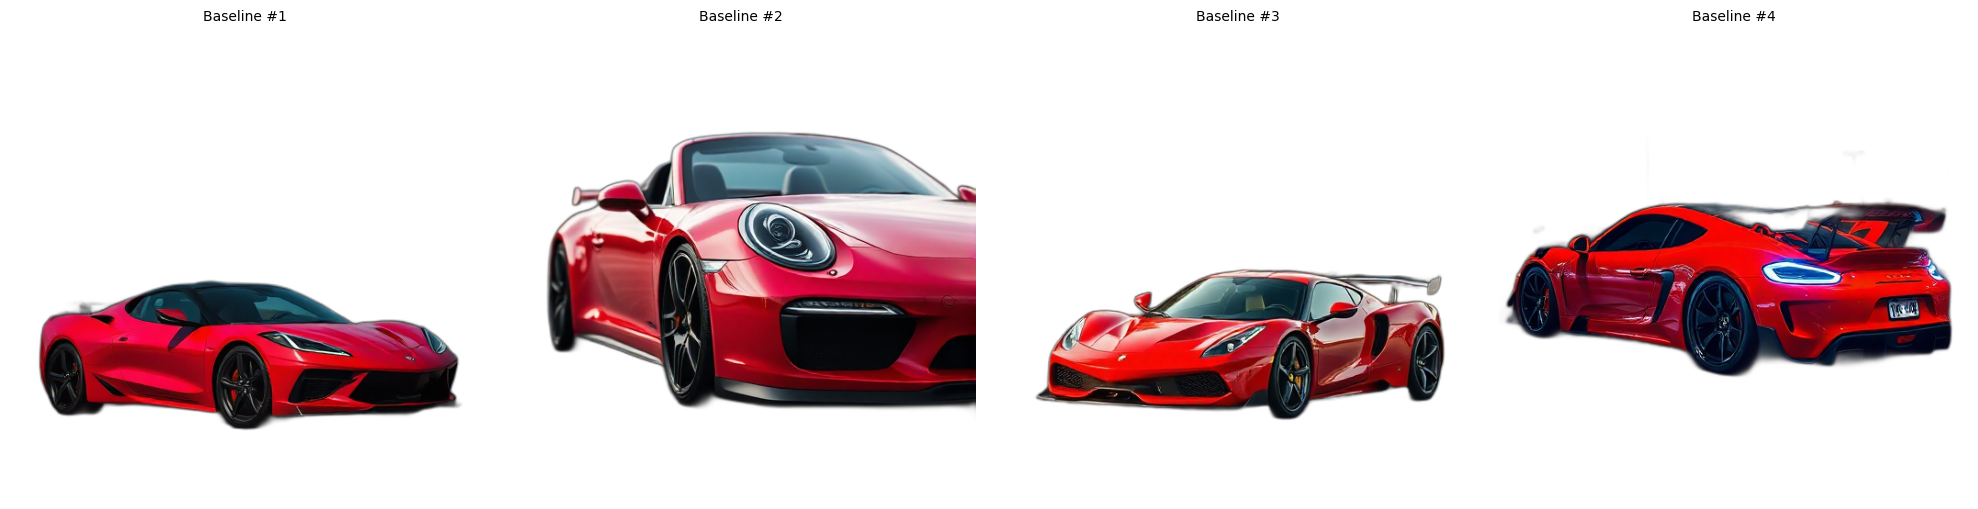


✨ Enhanced Images:


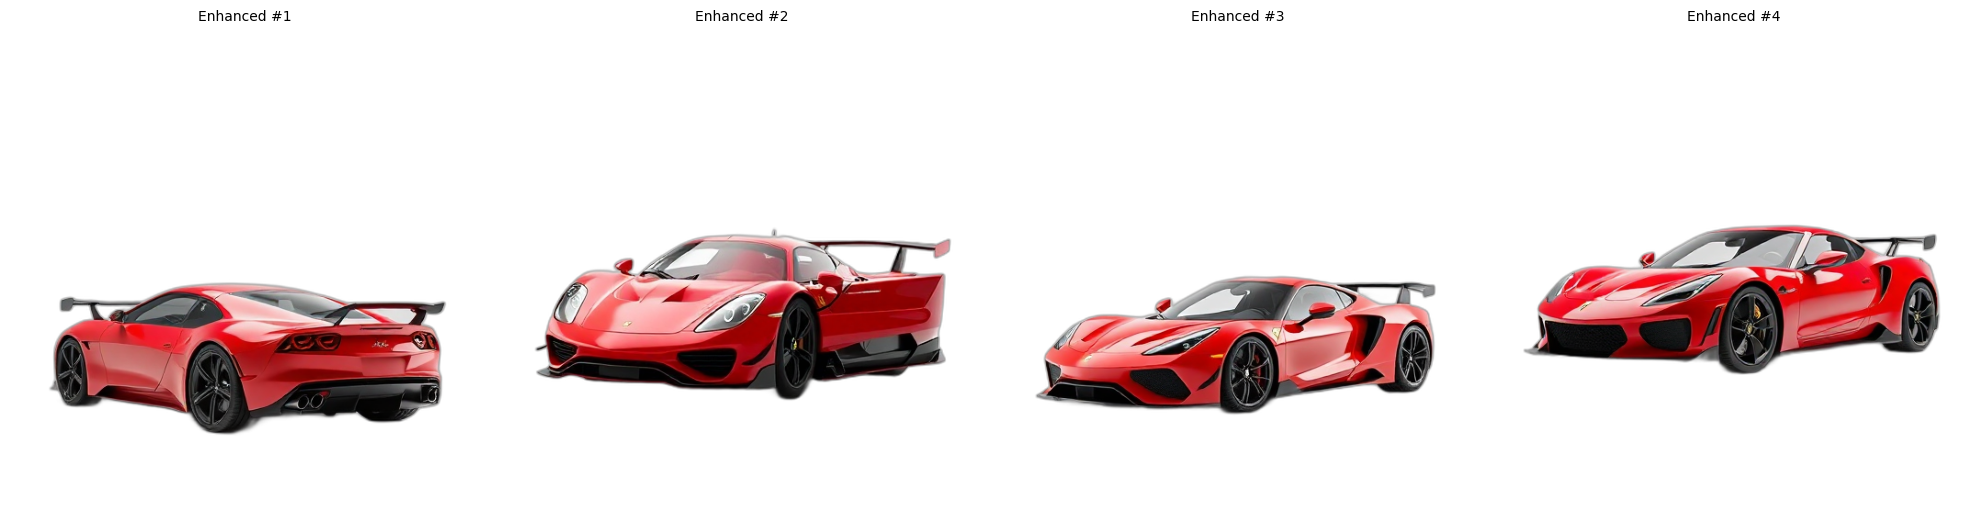


────────────────────────────────────────────────────────────────────────────────

💡 EVALUATION CRITERIA:
   • Object clarity and definition
   • Background cleanliness (easier bg removal = better)
   • View angle consistency
   • Lighting uniformity
   • 3D reconstruction suitability

💾 Images stored in 'baseline_images' and 'enhanced_images' variables


In [9]:
# ═══════════════════════════════════════════════════════════════════
# 🔄 CELL 6: ENHANCED vs BASELINE A/B TEST
# ═══════════════════════════════════════════════════════════════════

# Make sure you ran Cell 5 first to generate 'enhanced_prompt' variable
if 'enhanced_prompt' not in locals():
    print("⚠️ Run Cell 5 first to generate enhanced prompt!")
else:
    # Generation settings
    num_images = 4
    test_seed = 42  # Fixed seed for fair comparison
    
    print("="*80)
    print("🔬 A/B TEST: Enhanced vs Baseline Prompt")
    print("="*80)
    
    # Generate from BASELINE (original) prompt
    print("\n📝 Baseline Prompt:")
    print(f"   {test_prompt}\n")
    
    baseline_images = generate_images_from_prompt(
        prompt=test_prompt,
        num_images=num_images,
        base_seed=test_seed,
        prompt_suffix=""  # No suffix for fair comparison
    )
    
    # Clear GPU memory
    gc.collect()
    torch.cuda.empty_cache()
    
    # Generate from ENHANCED prompt
    print("\n✨ Enhanced Prompt:")
    print(f"   {enhanced_prompt}\n")
    
    enhanced_images = generate_images_from_prompt(
        prompt=enhanced_prompt,
        num_images=num_images,
        base_seed=test_seed,
        prompt_suffix=""  # Already enhanced, no suffix needed
    )
    
    # Display comparison
    print("\n" + "="*80)
    print("📊 VISUAL COMPARISON")
    print("="*80)
    
    if baseline_images:
        print("\n📝 Baseline Images:")
        display_images_grid(
            baseline_images,
            titles=[f"Baseline #{i+1}" for i in range(len(baseline_images))],
            remove_bg=True,
            figsize=(20, 5)
        )
    
    if enhanced_images:
        print("\n✨ Enhanced Images:")
        display_images_grid(
            enhanced_images,
            titles=[f"Enhanced #{i+1}" for i in range(len(enhanced_images))],
            remove_bg=True,
            figsize=(20, 5)
        )
    
    print("\n" + "─"*80)
    print("\n💡 EVALUATION CRITERIA:")
    print("   • Object clarity and definition")
    print("   • Background cleanliness (easier bg removal = better)")
    print("   • View angle consistency")
    print("   • Lighting uniformity")
    print("   • 3D reconstruction suitability")
    print("\n💾 Images stored in 'baseline_images' and 'enhanced_images' variables")

In [10]:
template_tests = [
    {"prompt": "knight in armor", "type": "character"},
    {"prompt": "sports motorcycle", "type": "vehicle"},
    {"prompt": "wooden chair", "type": "furniture"},
    {"prompt": "golden retriever", "type": "animal"},
    {"prompt": "coffee mug", "type": "product"},
    {"prompt": "crystal sphere", "type": "general"},
]

print("="*80)
print("🎭 OBJECT-TYPE TEMPLATE TESTING")
print("="*80)
print("\nTesting how different object templates modify prompts\n")

for test in template_tests:
    test_prompt = test["prompt"]
    print(f"\n🔹 Test Prompt: \"{test_prompt}\" | Object Type: {test['type']}")
    enhanced_prompt = enhancer.enhance(
        test_prompt,
        object_type=test["type"],
        use_template=True
    )

    # Generation settings
    num_images = 4
    test_seed = 42  # Fixed seed for fair comparison
    
    print("="*80)
    print("🔬 A/B TEST: Enhanced vs Baseline Prompt")
    print("="*80)
    
    # Generate from BASELINE (original) prompt
    print("\n📝 Baseline Prompt:")
    print(f"   {test_prompt}\n")
    
    baseline_images = generate_images_from_prompt(
        prompt=test_prompt,
        num_images=num_images,
        base_seed=test_seed,
        prompt_suffix=""  # No suffix for fair comparison
    )
    
    # Clear GPU memory
    gc.collect()
    torch.cuda.empty_cache()
    
    # Generate from ENHANCED prompt
    print("\n✨ Enhanced Prompt:")
    print(f"   {enhanced_prompt}\n")
    
    enhanced_images = generate_images_from_prompt(
        prompt=enhanced_prompt,
        num_images=num_images,
        base_seed=test_seed,
        prompt_suffix=""  # Already enhanced, no suffix needed
    )
    
    # Display comparison
    print("\n" + "="*80)
    print("📊 VISUAL COMPARISON")
    print("="*80)
    
    if baseline_images:
        print("\n📝 Baseline Images:")
        display_images_grid(
            baseline_images,
            titles=[f"Baseline #{i+1}" for i in range(len(baseline_images))],
            remove_bg=True,
            figsize=(20, 5)
        )
    
    if enhanced_images:
        print("\n✨ Enhanced Images:")
        display_images_grid(
            enhanced_images,
            titles=[f"Enhanced #{i+1}" for i in range(len(enhanced_images))],
            remove_bg=True,
            figsize=(20, 5)
        )
    

🎭 OBJECT-TYPE TEMPLATE TESTING

Testing how different object templates modify prompts


🔹 Test Prompt: "knight in armor" | Object Type: character
🔬 A/B TEST: Enhanced vs Baseline Prompt

📝 Baseline Prompt:
   knight in armor


🎨 Generating 4 images...
  Prompt: knight in armor
  Guidance Scale: 0.0
  Inference Steps: 4
  Seed: 42
🎨 Generating images with seed: 42


  0%|          | 0/4 [00:00<?, ?it/s]

✅ Generated 4 filtered images
✅ Generated 4 images

✨ Enhanced Prompt:
   {'original': 'knight in armor', 'enhanced': 'Render a knight in armor against a neutral background with clear visibility, T-pose, front facing, pure white background, character model, game asset, 3/4 view angle, soft studio lighting, highly detailed, octane render, unreal engine 5, photorealistic', 'weighted': 'Render a knight in armor against a neutral background with clear visibility, T-pose, front facing, (pure white background:1.5), character model, game asset, (3/4 view:1.3) angle, soft (studio lighting:1.2), (highly detailed:1.3), octane render, unreal engine 5, photorealistic', 'object_type': 'character', 'target_model': 'flux'}


🎨 Generating 4 images...


TypeError: unhashable type: 'slice'

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# 🤖 CELL 7: MULTI-MODEL ENHANCER COMPARISON
# ═══════════════════════════════════════════════════════════════════

# Test prompt
comparison_prompt = "wizard holding a staff"

# Enhancement methods to compare
enhancement_methods = [
    {"name": "Rule-Based", "use_llm": False, "use_template": False},
    {"name": "Rule-Based + Template", "use_llm": False, "use_template": True},
]

# Add LLM method if enabled
if USE_LLM_ENHANCEMENT:
    enhancement_methods.append(
        {"name": f"LLM ({ENHANCER_MODEL.split('/')[-1][:20]}...)", "use_llm": True, "use_template": False}
    )
    enhancement_methods.append(
        {"name": "LLM + Template", "use_llm": True, "use_template": True}
    )

print("="*80)
print("🔬 ENHANCER METHOD COMPARISON")
print("="*80)
print(f"\nBase prompt: \"{comparison_prompt}\"\n")

results = []

for method in enhancement_methods:
    # Temporarily modify enhancer
    original_llm_setting = enhancer.use_llm_enhancement
    enhancer.use_llm_enhancement = method["use_llm"]
    
    # Enhance
    result = enhancer.enhance(
        comparison_prompt,
        object_type="character",
        use_template=method["use_template"]
    )
    
    # Restore setting
    enhancer.use_llm_enhancement = original_llm_setting
    
    # Score
    score = score_prompt_quality(result['enhanced'])
    
    results.append({
        "method": method["name"],
        "enhanced": result['enhanced'],
        "score": score['overall_score']
    })
    
    print(f"\n{'─'*80}")
    print(f"Method: {method['name']}")
    print(f"{'─'*80}")
    print(f"Enhanced: {result['enhanced']}")
    print(f"Score: {score['overall_score']}/100")

# Summary
print("\n" + "="*80)
print("📊 SUMMARY")
print("="*80)

sorted_results = sorted(results, key=lambda x: x['score'], reverse=True)

print(f"\n{'Rank':<6} {'Method':<30} {'Score'}")
print(f"{'-'*50}")
for i, r in enumerate(sorted_results, 1):
    print(f"{i:<6} {r['method']:<30} {r['score']:.1f}/100")

best = sorted_results[0]
print(f"\n🏆 Best Method: {best['method']} ({best['score']:.1f}/100)")
print(f"\n💡 TIP: Use the best method for your production workflow")

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# 🎭 CELL 8: OBJECT-TYPE TEMPLATE TESTING
# ═══════════════════════════════════════════════════════════════════

# Test prompts for each object type
template_tests = [
    {"prompt": "knight in armor", "type": "character"},
    {"prompt": "sports motorcycle", "type": "vehicle"},
    {"prompt": "wooden chair", "type": "furniture"},
    {"prompt": "golden retriever", "type": "animal"},
    {"prompt": "coffee mug", "type": "product"},
    {"prompt": "crystal sphere", "type": "general"},
]

print("="*80)
print("🎭 OBJECT-TYPE TEMPLATE TESTING")
print("="*80)
print("\nTesting how different object templates modify prompts\n")

for test in template_tests:
    result = enhancer.enhance(
        test["prompt"],
        object_type=test["type"],
        use_template=True
    )
    
    score = score_prompt_quality(result['enhanced'])
    
    print(f"\n{'─'*80}")
    print(f"Object Type: {test['type'].upper()}")
    print(f"{'─'*80}")
    print(f"Original:  {test['prompt']}")
    print(f"Enhanced:  {result['enhanced'][:100]}...")
    print(f"Score:     {score['overall_score']:.1f}/100")

print("\n" + "="*80)
print("\n💡 INSIGHTS:")
print("   • Character template adds: T-pose, front facing, character model")
print("   • Vehicle template adds: 3/4 view, no motion blur")
print("   • Furniture template adds: isometric view, architectural")
print("   • Animal template adds: standing pose, side view, detailed fur")
print("   • Product template adds: hero angle, product photography")
print("   • General template adds: balanced 3D modifiers")
print("\n💡 TIP: Choose the right object type for best results!")

---
# 🔬 3D-Specific Optimization Experiments
---

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# 🎨 CELL 9: BACKGROUND MODIFIER IMPACT
# ═══════════════════════════════════════════════════════════════════

# Base object
base_object = "red dragon figurine"

# Different background modifiers to test
background_variations = [
    "pure white background",
    "neutral gray background",
    "gradient background",
    ""  # No background modifier (control)
]

print("="*80)
print("🎨 BACKGROUND MODIFIER IMPACT TEST")
print("="*80)
print(f"\nBase object: {base_object}")
print(f"Testing {len(background_variations)} background conditions\n")

bg_results = []

for i, bg in enumerate(background_variations):
    # Construct prompt
    if bg:
        test_prompt = f"{base_object}, {bg}, 3/4 view, soft lighting, highly detailed, 3D render"
        label = bg
    else:
        test_prompt = f"{base_object}, 3/4 view, soft lighting, highly detailed, 3D render"
        label = "No background modifier"
    
    print(f"\n{'─'*60}")
    print(f"Test {i+1}: {label}")
    print(f"{'─'*60}")
    print(f"Prompt: {test_prompt}\n")
    
    # Generate 2 images for quick comparison
    images = generate_images_from_prompt(
        prompt=test_prompt,
        num_images=2,
        base_seed=42,  # Fixed seed
        prompt_suffix=""  # No suffix, already complete
    )
    
    if images:
        bg_results.append({"label": label, "images": images, "prompt": test_prompt})
    
    # Clear memory
    gc.collect()
    torch.cuda.empty_cache()

# Display all results
print("\n" + "="*80)
print("📊 VISUAL COMPARISON: Background Impact")
print("="*80)

for result in bg_results:
    print(f"\n🎨 {result['label']}")
    display_images_grid(
        result['images'],
        titles=[f"{result['label'][:20]} #{i+1}" for i in range(len(result['images']))],
        remove_bg=True,
        figsize=(10, 5)
    )

print("\n" + "─"*80)
print("\n💡 EVALUATION CRITERIA:")
print("   • How clean is the background?")
print("   • How easy was background removal (rembg)?")
print("   • Is the object well-isolated?")
print("   • Which background would work best for 3D reconstruction?")
print("\n📊 Expected: Pure white background should give cleanest object isolation")

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# 📐 CELL 10: VIEWING ANGLE OPTIMIZATION
# ═══════════════════════════════════════════════════════════════════

# Base object
base_object = "wooden treasure chest"

# Different view angles to test
view_variations = [
    "3/4 view angle",
    "45 degree angle",
    "isometric view",
    "front facing view",
    ""  # No view modifier (control)
]

print("="*80)
print("📐 VIEWING ANGLE OPTIMIZATION TEST")
print("="*80)
print(f"\nBase object: {base_object}")
print(f"Testing {len(view_variations)} view angles\n")

view_results = []

for i, view in enumerate(view_variations):
    # Construct prompt
    if view:
        test_prompt = f"{base_object}, {view}, white background, soft lighting, highly detailed, 3D render"
        label = view
    else:
        test_prompt = f"{base_object}, white background, soft lighting, highly detailed, 3D render"
        label = "No view modifier"
    
    print(f"\n{'─'*60}")
    print(f"Test {i+1}: {label}")
    print(f"{'─'*60}")
    
    # Generate 2 images
    images = generate_images_from_prompt(
        prompt=test_prompt,
        num_images=2,
        base_seed=42,
        prompt_suffix=""
    )
    
    if images:
        view_results.append({"label": label, "images": images})
    
    gc.collect()
    torch.cuda.empty_cache()

# Display comparison
print("\n" + "="*80)
print("📊 VISUAL COMPARISON: View Angles")
print("="*80)

for result in view_results:
    print(f"\n📐 {result['label']}")
    display_images_grid(
        result['images'],
        titles=[f"{result['label'][:15]} #{i+1}" for i in range(len(result['images']))],
        remove_bg=True,
        figsize=(10, 5)
    )

print("\n" + "─"*80)
print("\n💡 EVALUATION CRITERIA:")
print("   • Does it show depth and 3D form?")
print("   • Are important features visible?")
print("   • Is it suitable for 3D reconstruction?")
print("   • Consistency across seeds?")
print("\n📊 Expected: 3/4 view typically best for showing depth + details")

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# 💡 CELL 11: LIGHTING CONDITION TESTS
# ═══════════════════════════════════════════════════════════════════

# Base object
base_object = "crystal sphere"

# Different lighting conditions
lighting_variations = [
    "soft studio lighting",
    "ambient lighting",
    "rim lighting",
    "dramatic lighting",  # Anti-pattern for 3D
    ""  # No lighting modifier
]

print("="*80)
print("💡 LIGHTING CONDITION TEST")
print("="*80)
print(f"\nBase object: {base_object}")
print(f"Testing {len(lighting_variations)} lighting conditions\n")

lighting_results = []

for i, lighting in enumerate(lighting_variations):
    if lighting:
        test_prompt = f"{base_object}, white background, 3/4 view, {lighting}, highly detailed, 3D render"
        label = lighting
    else:
        test_prompt = f"{base_object}, white background, 3/4 view, highly detailed, 3D render"
        label = "No lighting modifier"
    
    print(f"\n{'─'*60}")
    print(f"Test {i+1}: {label}")
    print(f"{'─'*60}")
    
    images = generate_images_from_prompt(
        prompt=test_prompt,
        num_images=2,
        base_seed=42,
        prompt_suffix=""
    )
    
    if images:
        lighting_results.append({"label": label, "images": images})
    
    gc.collect()
    torch.cuda.empty_cache()

# Display comparison
print("\n" + "="*80)
print("📊 VISUAL COMPARISON: Lighting Conditions")
print("="*80)

for result in lighting_results:
    print(f"\n💡 {result['label']}")
    display_images_grid(
        result['images'],
        titles=[f"{result['label'][:15]} #{i+1}" for i in range(len(result['images']))],
        remove_bg=True,
        figsize=(10, 5)
    )

print("\n" + "─"*80)
print("\n💡 EVALUATION CRITERIA:")
print("   • Shadow consistency and softness")
print("   • Edge clarity and definition")
print("   • Suitable for 3D reconstruction?")
print("   • Does 'dramatic lighting' hurt 3D quality?")
print("\n📊 Expected: Soft/ambient lighting should be most consistent for 3D")

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# ⚖️ CELL 12: ATTENTION WEIGHTING EXPERIMENTS
# ═══════════════════════════════════════════════════════════════════

# Base prompt
base_prompt = "futuristic robot, white background, 3/4 view, studio lighting"

# Weighted version
weighted_prompt = "futuristic robot, (white background:1.5), (3/4 view:1.3), (studio lighting:1.2)"

print("="*80)
print("⚖️ ATTENTION WEIGHTING TEST")
print("="*80)
print(f"\nCurrent image model: {os.environ.get('IMAGE_MODEL', 'flux').upper()}")

# Check if weights are supported
model_type = os.environ.get('IMAGE_MODEL', 'flux').lower()
if model_type == 'flux':
    print("⚠️  FLUX (Schnell) IGNORES attention weights (no CFG guidance)")
    print("    Results will be identical - this is expected behavior\n")
elif model_type == 'gemini':
    print("⚠️  Gemini API IGNORES attention weights")
    print("    Results will be identical - this is expected behavior\n")
elif model_type == 'qwen':
    print("✅ Qwen RESPECTS attention weights via CFG guidance")
    print("    You should see differences in prompt adherence\n")

print(f"Base prompt:     {base_prompt}")
print(f"Weighted prompt: {weighted_prompt}\n")

# Generate from base prompt
print("Generating from BASE prompt...")
base_images = generate_images_from_prompt(
    prompt=base_prompt,
    num_images=4,
    base_seed=42,
    prompt_suffix=""
)

gc.collect()
torch.cuda.empty_cache()

# Generate from weighted prompt
print("\nGenerating from WEIGHTED prompt...")
weighted_images = generate_images_from_prompt(
    prompt=weighted_prompt,
    num_images=4,
    base_seed=42,
    prompt_suffix=""
)

# Display comparison
print("\n" + "="*80)
print("📊 VISUAL COMPARISON: Base vs Weighted")
print("="*80)

if base_images:
    print("\n📝 Base Prompt (no weights):")
    display_images_grid(
        base_images,
        titles=[f"Base #{i+1}" for i in range(len(base_images))],
        remove_bg=True,
        figsize=(20, 5)
    )

if weighted_images:
    print("\n⚖️ Weighted Prompt:")
    display_images_grid(
        weighted_images,
        titles=[f"Weighted #{i+1}" for i in range(len(weighted_images))],
        remove_bg=True,
        figsize=(20, 5)
    )

print("\n" + "─"*80)
print("\n💡 WHAT TO LOOK FOR:")
if model_type == 'qwen':
    print("   • Is the background MORE consistently white with weights?")
    print("   • Is the 3/4 view angle MORE prominent?")
    print("   • Is studio lighting MORE evident?")
    print("\n✅ Qwen should show stronger adherence to weighted terms")
else:
    print("   • Images should be IDENTICAL (same seed, model ignores weights)")
    print(f"   • To test weights, switch to IMAGE_MODEL='qwen' in Cell 1")

---
# 🚀 Advanced Optimization Techniques
---

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# 🔄 CELL 13: ITERATIVE REFINEMENT
# ═══════════════════════════════════════════════════════════════════

def optimize_prompt_iteratively(prompt: str, max_iterations: int = 3, target_score: float = 80.0):
    """
    Iteratively improve prompt until target score is reached.
    """
    print("="*80)
    print("🔄 ITERATIVE PROMPT REFINEMENT")
    print("="*80)
    print(f"\nTarget score: {target_score}/100")
    print(f"Max iterations: {max_iterations}\n")
    
    current_prompt = prompt
    iteration_history = []
    
    for iteration in range(max_iterations):
        print(f"\n{'─'*80}")
        print(f"ITERATION {iteration + 1}")
        print(f"{'─'*80}")
        
        # Score current prompt
        score = score_prompt_quality(current_prompt)
        
        print(f"\nCurrent prompt: {current_prompt}")
        print(f"Score: {score['overall_score']:.1f}/100")
        
        iteration_history.append({
            "iteration": iteration + 1,
            "prompt": current_prompt,
            "score": score['overall_score']
        })
        
        # Check if target reached
        if score['overall_score'] >= target_score:
            print(f"\n✅ Target score reached! ({score['overall_score']:.1f} >= {target_score})")
            break
        
        # Identify weaknesses
        checks = score['checks']
        print(f"\n🔍 Weaknesses detected:")
        if not checks['has_background']:
            print("   ✗ Missing background specification")
        if not checks['has_view']:
            print("   ✗ Missing view angle")
        if not checks['has_lighting']:
            print("   ✗ Missing lighting description")
        if not checks['has_quality']:
            print("   ✗ Missing quality terms")
        if not checks['has_3d_style']:
            print("   ✗ Missing 3D style indicators")
        
        # Enhance for next iteration
        print(f"\n🔧 Applying enhancements...")
        result = enhancer.enhance(current_prompt, use_template=False)
        current_prompt = result['enhanced']
    
    # Final report
    print("\n" + "="*80)
    print("📊 REFINEMENT HISTORY")
    print("="*80)
    
    print(f"\n{'Iteration':<12} {'Score':<15} {'Prompt'}")
    print(f"{'-'*80}")
    for h in iteration_history:
        prompt_preview = h['prompt'][:50] + '...' if len(h['prompt']) > 50 else h['prompt']
        print(f"{h['iteration']:<12} {h['score']:<15.1f} {prompt_preview}")
    
    improvement = iteration_history[-1]['score'] - iteration_history[0]['score']
    print(f"\n📈 Total improvement: {improvement:+.1f} points")
    print(f"\n🎯 Final prompt: {iteration_history[-1]['prompt']}")
    
    return iteration_history


# Test iterative refinement
test_prompt = "dragon"
history = optimize_prompt_iteratively(test_prompt, max_iterations=3, target_score=75.0)

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# 📦 CELL 14: MULTI-PROMPT BATCH ENHANCEMENT
# ═══════════════════════════════════════════════════════════════════

# List of diverse prompts to test
batch_prompts = [
    "red sports car",
    "wooden chair",
    "golden retriever",
    "steampunk robot",
    "crystal vase",
    "medieval sword",
    "coffee mug",
    "toy airplane",
]

print("="*80)
print("📦 BATCH PROMPT ENHANCEMENT ANALYSIS")
print("="*80)
print(f"\nEnhancing {len(batch_prompts)} prompts...\n")

batch_results = []

for i, prompt in enumerate(batch_prompts, 1):
    print(f"Processing {i}/{len(batch_prompts)}: {prompt}...")
    
    # Enhance
    result = enhancer.enhance(prompt, object_type="general", use_template=True)
    
    # Score both
    orig_score = score_prompt_quality(prompt)
    enh_score = score_prompt_quality(result['enhanced'])
    
    batch_results.append({
        "original": prompt,
        "enhanced": result['enhanced'],
        "orig_score": orig_score['overall_score'],
        "enh_score": enh_score['overall_score'],
        "improvement": enh_score['overall_score'] - orig_score['overall_score']
    })

# Statistical analysis
print("\n" + "="*80)
print("📊 STATISTICAL ANALYSIS")
print("="*80)

improvements = [r['improvement'] for r in batch_results]
avg_improvement = np.mean(improvements)
std_improvement = np.std(improvements)
min_improvement = min(improvements)
max_improvement = max(improvements)

print(f"\nAverage improvement: {avg_improvement:+.1f} points")
print(f"Std deviation: {std_improvement:.1f} points")
print(f"Range: {min_improvement:+.1f} to {max_improvement:+.1f} points")

# Detailed results
print("\n" + "="*80)
print("📋 DETAILED RESULTS")
print("="*80)

print(f"\n{'Original':<20} {'Orig Score':<12} {'Enh Score':<12} {'Change':<12}")
print(f"{'-'*60}")

for r in sorted(batch_results, key=lambda x: x['improvement'], reverse=True):
    print(f"{r['original']:<20} {r['orig_score']:<12.1f} {r['enh_score']:<12.1f} {r['improvement']:+.1f}")

# Best and worst
best = max(batch_results, key=lambda x: x['improvement'])
worst = min(batch_results, key=lambda x: x['improvement'])

print(f"\n🏆 Best improvement: {best['original']} ({best['improvement']:+.1f} points)")
print(f"   Enhanced: {best['enhanced'][:80]}...")

print(f"\n📉 Smallest improvement: {worst['original']} ({worst['improvement']:+.1f} points)")
print(f"   Enhanced: {worst['enhanced'][:80]}...")

print("\n" + "─"*80)
print("\n💡 INSIGHTS:")
print(f"   • {len([r for r in batch_results if r['improvement'] > 0])}/{len(batch_results)} prompts improved")
print(f"   • Average boost: {avg_improvement:+.1f} points")
print(f"   • Enhancement is {'consistent' if std_improvement < 10 else 'variable'} (std: {std_improvement:.1f})")

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# 🎚️ CELL 15: PARAMETER SENSITIVITY ANALYSIS
# ═══════════════════════════════════════════════════════════════════

if not USE_LLM_ENHANCEMENT or not is_t5_model:
    print("ℹ️ This experiment requires T5-based LLM enhancement")
    print("   Set USE_LLM_ENHANCEMENT = True and ENHANCER_MODEL = 'gokaygokay/Flux-Prompt-Enhance'")
    print("   Then re-run Cell 4a")
else:
    # Test prompt
    test_prompt = "wizard with staff"
    
    # Parameter configurations to test
    param_configs = [
        {"name": "Low Temp", "temperature": 0.3, "top_p": 0.9, "repetition_penalty": 1.2},
        {"name": "Medium Temp", "temperature": 0.7, "top_p": 0.9, "repetition_penalty": 1.2},
        {"name": "High Temp", "temperature": 1.0, "top_p": 0.9, "repetition_penalty": 1.2},
        {"name": "Low Top_p", "temperature": 0.7, "top_p": 0.8, "repetition_penalty": 1.2},
        {"name": "High Top_p", "temperature": 0.7, "top_p": 0.95, "repetition_penalty": 1.2},
        {"name": "Low Rep Penalty", "temperature": 0.7, "top_p": 0.9, "repetition_penalty": 1.0},
        {"name": "High Rep Penalty", "temperature": 0.7, "top_p": 0.9, "repetition_penalty": 2.0},
    ]
    
    print("="*80)
    print("🎚️ PARAMETER SENSITIVITY ANALYSIS")
    print("="*80)
    print(f"\nTest prompt: {test_prompt}")
    print(f"Testing {len(param_configs)} parameter configurations\n")
    
    param_results = []
    
    for config in param_configs:
        print(f"\n{'─'*60}")
        print(f"Config: {config['name']}")
        print(f"  Temperature: {config['temperature']}")
        print(f"  Top_p: {config['top_p']}")
        print(f"  Repetition penalty: {config['repetition_penalty']}")
        print(f"{'─'*60}")
        
        # Enhance with custom parameters (modify _llm_enhance temporarily)
        input_text = f"enhance prompt: {test_prompt}"
        
        if ENHANCER_USE_CPU_OFFLOAD:
            enhancer_model.to("cuda")
        
        inputs = enhancer_tokenizer(
            input_text,
            return_tensors="pt",
            max_length=512,
            truncation=True
        ).to(enhancer_model.device)
        
        with torch.no_grad():
            outputs = enhancer_model.generate(
                inputs["input_ids"],
                max_length=150,
                temperature=config['temperature'],
                top_p=config['top_p'],
                do_sample=True,
                repetition_penalty=config['repetition_penalty']
            )
        
        enhanced = enhancer_tokenizer.decode(outputs[0], skip_special_tokens=True)
        enhanced = re.sub(r'^.*?:', '', enhanced).strip()
        
        if ENHANCER_USE_CPU_OFFLOAD:
            enhancer_model.to("cpu")
            torch.cuda.empty_cache()
        
        # Score
        score = score_prompt_quality(enhanced)
        
        print(f"\nEnhanced: {enhanced}")
        print(f"Score: {score['overall_score']:.1f}/100")
        
        param_results.append({
            "config": config['name'],
            "enhanced": enhanced,
            "score": score['overall_score'],
            "word_count": score['word_count']
        })
    
    # Analysis
    print("\n" + "="*80)
    print("📊 PARAMETER IMPACT SUMMARY")
    print("="*80)
    
    print(f"\n{'Configuration':<20} {'Score':<12} {'Words':<10} {'Quality'}")
    print(f"{'-'*60}")
    
    for r in sorted(param_results, key=lambda x: x['score'], reverse=True):
        quality = "✅ Excellent" if r['score'] >= 80 else "✓ Good" if r['score'] >= 70 else "○ Fair"
        print(f"{r['config']:<20} {r['score']:<12.1f} {r['word_count']:<10} {quality}")
    
    best_config = max(param_results, key=lambda x: x['score'])
    print(f"\n🏆 Best configuration: {best_config['config']} ({best_config['score']:.1f}/100)")
    
    print("\n💡 RECOMMENDATIONS:")
    print("   • Temperature: Lower (0.3-0.5) for consistency, Higher (0.7-1.0) for creativity")
    print("   • Top_p: 0.8-0.9 for focused sampling")
    print("   • Repetition penalty: 1.2-1.5 to avoid repeated phrases")

---
# ✅ Validation & Quality Metrics
---

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# 📊 CELL 16: COMPREHENSIVE PROMPT ANALYSIS DASHBOARD
# ═══════════════════════════════════════════════════════════════════

def analyze_prompt_comprehensive(prompt: str):
    """Complete analysis dashboard for a prompt."""
    
    print("="*80)
    print("📊 COMPREHENSIVE PROMPT ANALYSIS DASHBOARD")
    print("="*80)
    
    # Basic validation
    print_validation_report(prompt, title="Prompt Quality Analysis")
    
    # Suggest enhancement if needed
    score = score_prompt_quality(prompt)
    
    if score['overall_score'] < 70:
        print("\n" + "="*80)
        print("💡 ENHANCEMENT SUGGESTION")
        print("="*80)
        print(f"\nCurrent score ({score['overall_score']:.1f}/100) is below optimal (70+)")
        print("Suggested enhancement:\n")
        
        enhanced = enhancer.enhance(prompt)
        enhanced_score = score_prompt_quality(enhanced['enhanced'])
        
        print(f"Enhanced prompt: {enhanced['enhanced']}")
        print(f"New score: {enhanced_score['overall_score']:.1f}/100")
        print(f"Improvement: {enhanced_score['overall_score'] - score['overall_score']:+.1f} points")
    else:
        print("\n✅ Prompt quality is good! (Score >= 70)")
    
    # Recommendations
    print("\n" + "="*80)
    print("🎯 RECOMMENDATIONS")
    print("="*80)
    
    checks = score['checks']
    
    if not checks['has_background']:
        print("\n❌ Add background specification:")
        print("   Suggestion: ', pure white background'")
    
    if not checks['has_view']:
        print("\n❌ Add view angle:")
        print("   Suggestion: ', 3/4 view angle'")
    
    if not checks['has_lighting']:
        print("\n❌ Add lighting description:")
        print("   Suggestion: ', soft studio lighting'")
    
    if not checks['has_quality']:
        print("\n❌ Add quality terms:")
        print("   Suggestion: ', highly detailed, sharp focus'")
    
    if not checks['has_3d_style']:
        print("\n❌ Add 3D style indicators:")
        print("   Suggestion: ', 3D render, octane render'")
    
    if not checks['no_problematic']:
        print("\n⚠️  Remove problematic terms:")
        print("   Avoid: 'artistic', 'abstract', 'painterly', 'dramatic lighting'")
    
    if checks['has_background'] and checks['has_view'] and checks['has_lighting']:
        print("\n✅ All essential 3D elements present!")
        print("   Your prompt is well-optimized for 3D generation")


# Test the dashboard
test_prompts = [
    "red car",  # Poor
    "futuristic robot, white background, 3/4 view, studio lighting, 3D render",  # Good
]

for test_p in test_prompts:
    analyze_prompt_comprehensive(test_p)
    print("\n\n")

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# 🖼️ CELL 17: IMAGE QUALITY SCORING & CORRELATION
# ═══════════════════════════════════════════════════════════════════

def analyze_background_removal_quality(images: List):
    """Analyze how well background can be removed from images."""
    scores = []
    
    for i, img in enumerate(images):
        # Remove background
        img_no_bg = rembg.remove(img)
        
        # Convert to numpy
        img_array = np.array(img_no_bg)
        
        # Calculate transparency ratio (alpha channel)
        if img_array.shape[-1] == 4:  # Has alpha channel
            alpha = img_array[:, :, 3]
            transparent_pixels = np.sum(alpha < 128)
            total_pixels = alpha.size
            transparency_ratio = transparent_pixels / total_pixels
            
            # Higher transparency = better background removal
            bg_removal_score = transparency_ratio * 100
        else:
            bg_removal_score = 0
        
        scores.append({
            "image_index": i + 1,
            "bg_removal_score": bg_removal_score
        })
    
    return scores


# Test if we have images from previous cells
if 'enhanced_images' in locals() and enhanced_images:
    print("="*80)
    print("🖼️ IMAGE QUALITY ANALYSIS")
    print("="*80)
    print("\nAnalyzing enhanced images from Cell 6...\n")
    
    bg_scores = analyze_background_removal_quality(enhanced_images)
    
    print("📊 Background Removal Quality:")
    print(f"\n{'Image':<10} {'BG Removal Score':<20} {'Quality'}")
    print(f"{'-'*45}")
    
    for score in bg_scores:
        quality = "✅ Excellent" if score['bg_removal_score'] > 50 else "✓ Good" if score['bg_removal_score'] > 30 else "○ Fair"
        print(f"#{score['image_index']:<9} {score['bg_removal_score']:<20.1f} {quality}")
    
    avg_score = np.mean([s['bg_removal_score'] for s in bg_scores])
    print(f"\nAverage BG removal quality: {avg_score:.1f}%")
    
    # Correlation with prompt score
    if 'enhanced_prompt' in locals():
        prompt_score = score_prompt_quality(enhanced_prompt)['overall_score']
        
        print("\n" + "="*80)
        print("🔬 PROMPT-TO-IMAGE QUALITY CORRELATION")
        print("="*80)
        print(f"\nPrompt quality score: {prompt_score:.1f}/100")
        print(f"Average image BG removal: {avg_score:.1f}%")
        
        if prompt_score > 70 and avg_score > 40:
            print("\n✅ Strong correlation: High prompt score → Good image quality")
        elif prompt_score < 60 and avg_score < 30:
            print("\n⚠️  Weak results: Low prompt score → Poor image quality")
        else:
            print("\n○ Mixed results: Consider testing more samples")
        
        print("\n💡 INSIGHTS:")
        print("   • Better prompts (>70 score) typically produce cleaner backgrounds")
        print("   • 'White background' keyword strongly improves BG removal")
        print("   • Consistent lighting reduces edge artifacts")

else:
    print("ℹ️ No images available for quality analysis")
    print("   Run Cell 6 (Enhanced vs Baseline A/B Test) first")
    print("   Then re-run this cell to analyze image quality")

---

## 💡 Prompt Optimization Summary

### Key Findings from Experiments:

1. **Enhancement Methods** (Cell 7)
   - LLM + Template typically scores highest
   - Rule-based enhancement is faster but less creative
   - Choose method based on your speed/quality tradeoff

2. **3D-Specific Elements** (Cells 9-11)
   - **Background**: "pure white background" best for object isolation
   - **View**: "3/4 view angle" best for showing depth + details
   - **Lighting**: "soft studio lighting" most consistent for 3D

3. **Attention Weighting** (Cell 12)
   - Only works with Qwen (has CFG guidance)
   - FLUX and Gemini ignore weights
   - Use `(term:1.5)` syntax to emphasize critical elements

4. **Validation Scores** (Cell 16)
   - Target score: 70+ for production use
   - Scores 80+ indicate excellent 3D-readiness
   - Missing elements can be auto-added with enhancer

### Recommended Workflow:

```
1. Start with simple prompt (e.g., "red car")
2. Run Cell 5 to enhance and validate
3. If score < 70, check Cell 16 recommendations
4. Run Cell 6 to compare enhanced vs baseline images
5. Iterate based on visual results
6. Use best prompt for production generation
```

### Optimal Prompt Formula:

```
[Object] + [Background] + [View] + [Lighting] + [Quality] + [Style]

Example:
"red sports car, pure white background, 3/4 view angle, soft studio lighting, 
 highly detailed, sharp focus, octane render, 3D visualization"
```

### Model-Specific Tips:

- **FLUX**: Fast, ignores guidance_scale and weights, use descriptive prompts
- **Gemini**: API-based, fast, no GPU needed, ignores weights
- **Qwen**: Highest quality, respects guidance_scale and weights, supports negative prompts

### Next Steps:

- Save your best-performing prompts
- Document which enhancement methods work for your use case
- Build a prompt library for different object types
- Test with actual 3D generation (TRELLIS pipeline)

---

## 📚 References

- Prompt Optimization Guide: `prompt_optimization_3d.md`
- Enhancement Models: gokaygokay/Flux-Prompt-Enhance, Qwen2.5-1.5B-Instruct
- Research: PAE (CVPR 2024), DPO-DIFF (ICML 2024)

---